# Text Model — TF-IDF + Logistic Regression

**Dataset:** `text_data.csv` (output from preprocessing pipeline)

**Task:** Binary classification — Fake (0) vs Real (1) news

**Approach:** TF-IDF vectorisation on cleaned text → Logistic Regression classifier

This serves as the **baseline model** that BERT and other models will be compared against.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from scipy.sparse import hstack

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
print('✓ Imports done')

/Users/zan_zxc/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


✓ Imports done


## 2. Load Data

In [2]:
df = pd.read_csv('/Applications/MAMP/htdocs/IS212/FakeDet/text_data.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (62338, 12)
Columns: ['title', 'text', 'label', 'text_len', 'title_len', 'title_word_count', 'text_word_count', 'text_char_count', 'title_tokens', 'text_tokens', 'title_cleaned', 'text_cleaned']


,title,text,label,text_len,title_len,title_word_count,text_word_count,text_char_count,title_tokens,text_tokens,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,871,18,18,871,5049,"['law', 'enforcement', 'high', 'alert', 'follo...","['no', 'comment', 'expect', 'barack', 'obama',...",law enforcement high alert follow threat cop w...,no comment expect barack obama member fyf fuky...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,34,18,18,34,216,"['unbelievable', 'obama', 'attorney', 'general...","['demonstrator', 'gather', 'last', 'night', 'e...",unbelievable obama attorney general say charlo...,demonstrator gather last night exercise consti...
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,1321,16,16,1321,8010,"['bobby', 'jindal', 'raise', 'hindu', 'us', 's...","['dozen', 'politically', 'active', 'pastor', '...",bobby jindal raise hindu us story christian co...,dozen politically active pastor come private d...
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,329,16,16,329,1916,"['satan', 'russia', 'unvelis', 'image', 'terri...","['r', 'sarmat', 'missile', 'dub', 'satan', 're...",satan russia unvelis image terrify new supernu...,r sarmat missile dub satan replace ss fly mile...
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,244,13,13,244,1530,"['time', 'christian', 'group', 'sue', 'amazon'...","['say', 'one', 'time', 'someone', 'sue', 'sout...",time christian group sue amazon splc designati...,say one time someone sue southern poverty law ...


In [3]:
# Sanity checks
print(f"Missing in text_cleaned:  {df['text_cleaned'].isnull().sum()}")
print(f"Missing in title_cleaned: {df['title_cleaned'].isnull().sum()}")
print(f"Missing in label:         {df['label'].isnull().sum()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

# Fill any nulls just in case
df['text_cleaned']  = df['text_cleaned'].fillna('')
df['title_cleaned'] = df['title_cleaned'].fillna('')

Missing in text_cleaned:  45
Missing in title_cleaned: 163
Missing in label:         0

Label distribution:
label
0    34782
1    27556
Name: count, dtype: int64


## 3. Prepare Features

We combine `title_cleaned` and `text_cleaned` into a single string per article.
Title words are repeated 3 times to give them more weight — titles are short but highly informative.

In [4]:
# Combine title (weighted x3) + body text into one string
# Repeating the title gives it more influence in the TF-IDF matrix
df['combined'] = df['title_cleaned'] + ' ' + df['title_cleaned'] + ' ' + df['title_cleaned'] + ' ' + df['text_cleaned']

X = df['combined']
y = df['label']

print(f'Total samples: {len(X)}')
print(f'Sample combined text (first 200 chars):')
print(X.iloc[0][:200])

Total samples: 62338
Sample combined text (first 200 chars):
law enforcement high alert follow threat cop white blacklivesmatter fyf terrorist video law enforcement high alert follow threat cop white blacklivesmatter fyf terrorist video law enforcement high ale


## 4. Train / Val / Test Split

80% train, 10% val, 10% test — stratified to preserve class balance.

In [5]:
# 80 / 10 / 10 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'Train: {len(X_train):,}  (Fake={( y_train==0).sum():,}, Real={(y_train==1).sum():,})')
print(f'Val:   {len(X_val):,}  (Fake={(y_val==0).sum():,}, Real={(y_val==1).sum():,})')
print(f'Test:  {len(X_test):,}  (Fake={(y_test==0).sum():,}, Real={(y_test==1).sum():,})')

Train: 49,870  (Fake=27,825, Real=22,045)
Val:   6,234  (Fake=3,478, Real=2,756)
Test:  6,234  (Fake=3,479, Real=2,755)


## 5. TF-IDF Vectorisation

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into a numerical matrix where:
- **TF** — how often a word appears in a document
- **IDF** — how rare the word is across all documents (rare words get higher weight)

We fit the vectoriser on training data only, then transform val and test — no data leakage.

In [6]:
tfidf = TfidfVectorizer(
    max_features=50000,    # keep top 50k words by frequency
    ngram_range=(1, 2),    # use single words AND pairs (e.g. 'fake news', 'breaking story')
    min_df=3,              # ignore words that appear in fewer than 3 documents
    max_df=0.95,           # ignore words that appear in more than 95% of documents (too common)
    sublinear_tf=True      # apply log normalisation to term frequency
)

# Fit on train only — transform all splits
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_):,}')

TF-IDF matrix shape (train): (49870, 50000)
Vocabulary size: 50,000


## 6. Add Length Features

We append the numeric length features from preprocessing as extra columns.
These give the model information TF-IDF alone can't capture.

In [7]:
from scipy.sparse import hstack, csr_matrix

length_cols = ['title_word_count', 'text_word_count', 'text_char_count']

# Check if length features exist in the csv
if all(c in df.columns for c in length_cols):
    # Align with splits using index
    len_train = csr_matrix(df.loc[X_train.index, length_cols].values)
    len_val   = csr_matrix(df.loc[X_val.index,   length_cols].values)
    len_test  = csr_matrix(df.loc[X_test.index,  length_cols].values)

    X_train_final = hstack([X_train_tfidf, len_train])
    X_val_final   = hstack([X_val_tfidf,   len_val])
    X_test_final  = hstack([X_test_tfidf,  len_test])
    print('✓ Length features appended')
else:
    # Fall back to TF-IDF only
    X_train_final = X_train_tfidf
    X_val_final   = X_val_tfidf
    X_test_final  = X_test_tfidf
    print('Length feature columns not found — using TF-IDF only')

print(f'Final feature matrix shape (train): {X_train_final.shape}')

✓ Length features appended
Final feature matrix shape (train): (49870, 50003)


## 7. Train Logistic Regression

In [8]:
lr = LogisticRegression(
    C=1.0,              # regularisation strength (lower = stronger regularisation)
    max_iter=1000,      # enough iterations to converge on large sparse data
    solver='lbfgs',     # efficient solver for large datasets
    random_state=RANDOM_STATE
)

lr.fit(X_train_final, y_train)
print('✓ Model trained')

✓ Model trained


## 8. Evaluate on Validation Set

Use the val set to check performance before touching the test set.

In [9]:
y_val_pred = lr.predict(X_val_final)

print('=== Validation Set Results ===')
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_val_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Fake', 'Real']))

=== Validation Set Results ===
Accuracy:  0.9670
Precision: 0.9691
Recall:    0.9557
F1 Score:  0.9624

Classification Report:
              precision    recall  f1-score   support

        Fake       0.97      0.98      0.97      3478
        Real       0.97      0.96      0.96      2756

    accuracy                           0.97      6234
   macro avg       0.97      0.97      0.97      6234
weighted avg       0.97      0.97      0.97      6234



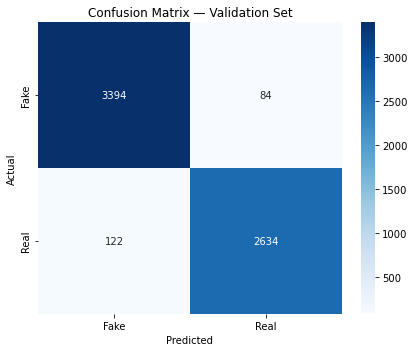

In [10]:
# Confusion matrix — validation
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## 9. Evaluate on Test Set

Only run this once you're happy with the val results — this is your final reported number.

In [11]:
y_test_pred = lr.predict(X_test_final)

print('=== Test Set Results (Final) ===')
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Fake', 'Real']))

=== Test Set Results (Final) ===
Accuracy:  0.9637
Precision: 0.9651
Recall:    0.9525
F1 Score:  0.9587

Classification Report:
              precision    recall  f1-score   support

        Fake       0.96      0.97      0.97      3479
        Real       0.97      0.95      0.96      2755

    accuracy                           0.96      6234
   macro avg       0.96      0.96      0.96      6234
weighted avg       0.96      0.96      0.96      6234



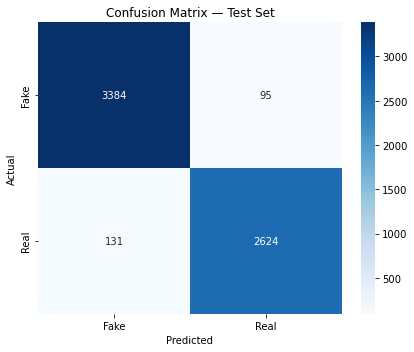

In [12]:
# Confusion matrix — test
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

## 10. Inspect Most Informative Features

Shows which words most strongly predict Fake vs Real news — good for understanding what the model learned.

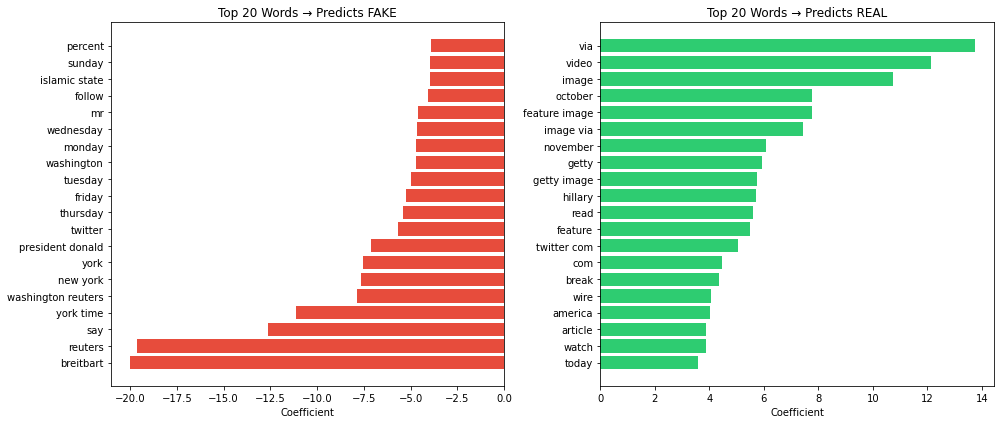

In [13]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr.coef_[0][:len(feature_names)]  # TF-IDF features only

top_n = 20
top_fake_idx = np.argsort(coefs)[:top_n]   # most negative = predicts Fake
top_real_idx = np.argsort(coefs)[-top_n:]  # most positive = predicts Real

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top words for Fake
axes[0].barh(feature_names[top_fake_idx], coefs[top_fake_idx], color='#e74c3c')
axes[0].set_title(f'Top {top_n} Words → Predicts FAKE')
axes[0].set_xlabel('Coefficient')

# Top words for Real
axes[1].barh(feature_names[top_real_idx], coefs[top_real_idx], color='#2ecc71')
axes[1].set_title(f'Top {top_n} Words → Predicts REAL')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

## 11. Save Model (Optional)

Saves the trained vectoriser and model so you don't have to retrain next time.

In [14]:
import joblib

joblib.dump(tfidf, '/Users/zan_zxc/Downloads/tfidf_vectorizer.pkl')
joblib.dump(lr,    '/Users/zan_zxc/Downloads/logistic_regression_model.pkl')

print('✓ Saved tfidf_vectorizer.pkl')
print('✓ Saved logistic_regression_model.pkl')

# To load later:
# tfidf = joblib.load('tfidf_vectorizer.pkl')
# lr    = joblib.load('logistic_regression_model.pkl')

✓ Saved tfidf_vectorizer.pkl
✓ Saved logistic_regression_model.pkl


: 

In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print(f"\n✓ Using Apple MPS GPU")
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"\n✓ Using CUDA GPU: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device('cpu')
    print(f"\n✗ No GPU found — using CPU")

print(f"Device set to: {DEVICE}")

PyTorch version: 2.2.2
CUDA available: False
MPS available: True

✓ Using Apple MPS GPU
Device set to: mps
